In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RESULT_PATH = "D:\\IE403\\ViAIGS\\output\\judge_results.csv"

df = pd.read_csv(RESULT_PATH)

print(df.shape)
df.head()

(9001, 36)


,judge_item_id,original_id,candidate_id,generator,source,original_text,candidate_text,surface_similarity,empty_original,empty_candidate,...,social_style_score,language_consistency_score,ai_artifact_score,dataset_usefulness_score,overall_quality_score,decision,final_decision,reason,raw_judge_response,judge_error
0,aya::human_013660_para_r1,human_013660,human_013660_para_r1,aya,fb,Nguyễn Bích Như học tập đi,"Nâng niu mơ ước, Nguyễn Bích Như hãy cố gắng h...",0.5455,False,False,...,NaN,NaN,NaN,NaN,NaN,drop,drop,Dropped by rule-based precheck.,NaN,NaN
1,aya::human_025981_para_r3,human_025981,human_025981_para_r3,aya,ytb,Trên đất nước nghèo đói của Việt Nam có mấy n...,"Trên đất nước Việt Nam nghèo khó, có những cá ...",0.2016,False,False,...,NaN,NaN,NaN,NaN,NaN,drop,drop,Dropped by rule-based precheck.,NaN,NaN
2,aya::human_028119_para_r2,human_028119,human_028119_para_r2,aya,ytb,Mình giới thiệu 1 cuốn sách trinh thám kinh đi...,"Cuốn sách trinh thám kinh điển, ra mắt vào năm...",0.3071,False,False,...,NaN,NaN,NaN,NaN,NaN,drop,drop,Dropped by rule-based precheck.,NaN,NaN
3,aya::human_016713_para_r3,human_016713,human_016713_para_r3,aya,ytb,Mua dép thì phải làm như thế nào ạ?,"Khi mua dép, bạn cần lưu ý những điều sau đây ...",0.3765,False,False,...,NaN,NaN,NaN,NaN,NaN,drop,drop,Dropped by rule-based precheck.,NaN,NaN
4,aya::human_014594_para_r3,human_014594,human_014594_para_r3,aya,fb,Thảo Uyên Nguyễn,Thảo Uyên Nguyễn vừa bày tỏ tâm trạng mới nhất...,0.3556,False,False,...,NaN,NaN,NaN,NaN,NaN,drop,drop,Dropped by rule-based precheck.,NaN,NaN


In [2]:
total = len(df)

summary = {
    "total_samples": total,
    "keep": (df["final_decision"] == "keep").sum(),
    "review": (df["final_decision"] == "review").sum(),
    "drop": (df["final_decision"] == "drop").sum(),
    "keep_rate": (df["final_decision"] == "keep").mean(),
    "review_rate": (df["final_decision"] == "review").mean(),
    "drop_rate": (df["final_decision"] == "drop").mean(),
    "avg_overall_quality": df["overall_quality_score"].mean(),
    "invalid_json_or_judge_error_rate": df["judge_error"].notna().mean(),
}

pd.DataFrame([summary])

,total_samples,keep,review,drop,keep_rate,review_rate,drop_rate,avg_overall_quality,invalid_json_or_judge_error_rate
0,9001,138,55,8808,0.015332,0.00611,0.978558,4.223272,0.005444


In [3]:
generator_summary = (
    df.groupby("generator")
    .agg(
        total=("judge_item_id", "count"),
        keep=("final_decision", lambda x: (x == "keep").sum()),
        review=("final_decision", lambda x: (x == "review").sum()),
        drop=("final_decision", lambda x: (x == "drop").sum()),
        avg_overall_quality=("overall_quality_score", "mean"),
        avg_meaning=("meaning_score", "mean"),
        avg_naturalness=("naturalness_score", "mean"),
        avg_social_style=("social_style_score", "mean"),
        avg_language=("language_consistency_score", "mean"),
        avg_ai_artifact=("ai_artifact_score", "mean"),
        avg_usefulness=("dataset_usefulness_score", "mean"),
    )
    .reset_index()
)

generator_summary["keep_rate"] = generator_summary["keep"] / generator_summary["total"]
generator_summary["review_rate"] = generator_summary["review"] / generator_summary["total"]
generator_summary["drop_rate"] = generator_summary["drop"] / generator_summary["total"]

generator_summary.sort_values("keep_rate", ascending=False)

,generator,total,keep,review,drop,avg_overall_quality,avg_meaning,avg_naturalness,avg_social_style,avg_language,avg_ai_artifact,avg_usefulness,keep_rate,review_rate,drop_rate
3,gpt,2064,86,17,1961,4.632705,4.656678,4.342466,4.953767,4.988870,1.337329,4.750000,0.041667,0.008236,0.950097
0,aya,1700,32,14,1654,4.262349,4.201976,4.145993,4.818880,4.882547,1.331504,4.451153,0.018824,0.008235,0.972941
2,gemma,1614,7,3,1604,3.991150,3.850664,3.987832,4.726770,4.867257,1.237832,4.245575,0.004337,0.001859,0.993804
1,deepseek,1897,8,15,1874,4.270358,4.222584,4.079262,4.856678,4.914224,1.172638,4.464712,0.004217,0.007907,0.987876
4,sailor,1726,5,6,1715,3.817970,3.616103,3.844807,4.609102,4.746791,1.396733,4.061844,0.002897,0.003476,0.993627


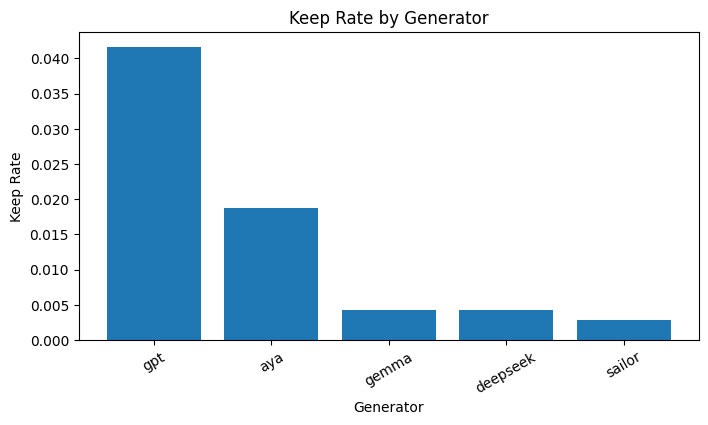

In [4]:
plot_df = generator_summary.sort_values("keep_rate", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(plot_df["generator"], plot_df["keep_rate"])
plt.title("Keep Rate by Generator")
plt.xlabel("Generator")
plt.ylabel("Keep Rate")
plt.xticks(rotation=30)
plt.show()

In [5]:
source_summary = (
    df.groupby("source")
    .agg(
        total=("judge_item_id", "count"),
        keep_rate=("final_decision", lambda x: (x == "keep").mean()),
        review_rate=("final_decision", lambda x: (x == "review").mean()),
        drop_rate=("final_decision", lambda x: (x == "drop").mean()),
        avg_quality=("overall_quality_score", "mean"),
        avg_social_style=("social_style_score", "mean"),
    )
    .reset_index()
)

source_summary.sort_values("drop_rate", ascending=False)

,source,total,keep_rate,review_rate,drop_rate,avg_quality,avg_social_style
1,voz,3106,0.013522,0.004829,0.981648,4.143277,4.791330
2,ytb,3069,0.014337,0.007820,0.977843,4.311942,4.797991
0,fb,2826,0.018401,0.005662,0.975938,4.192164,4.821517


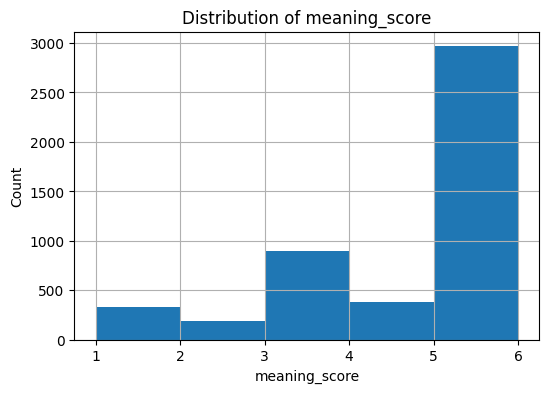

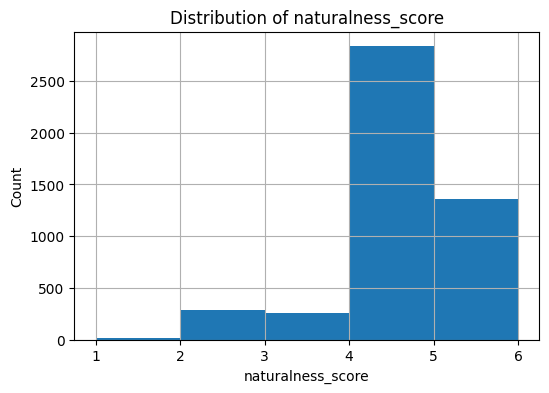

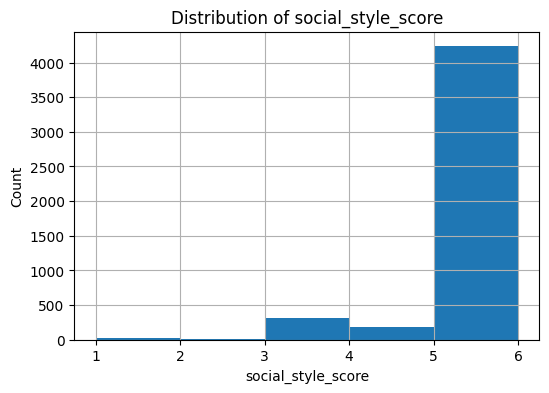

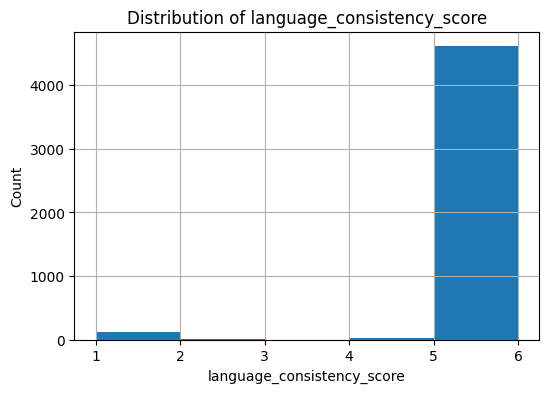

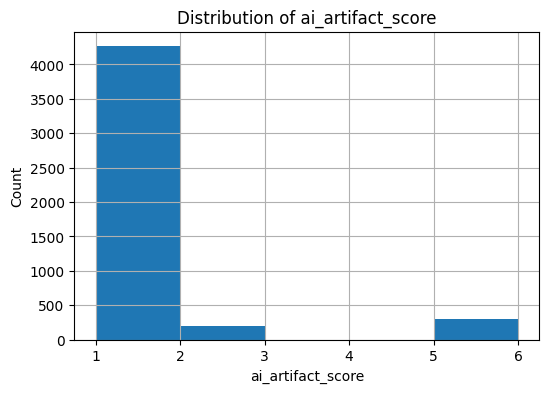

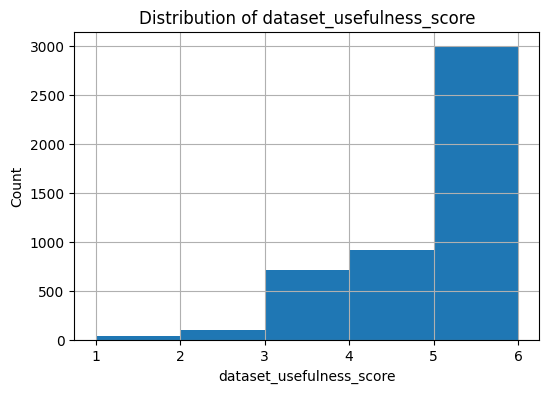

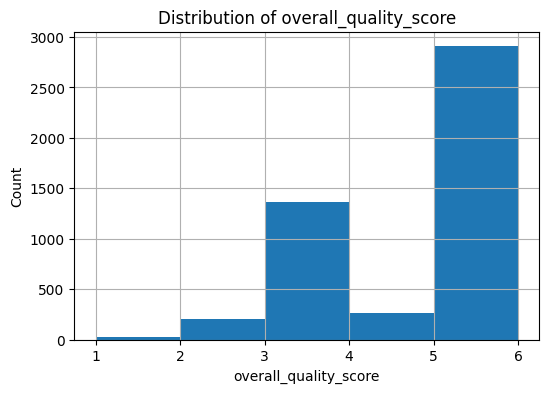

In [6]:
score_cols = [
    "meaning_score",
    "naturalness_score",
    "social_style_score",
    "language_consistency_score",
    "ai_artifact_score",
    "dataset_usefulness_score",
    "overall_quality_score",
]

for col in score_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().hist(bins=[1, 2, 3, 4, 5, 6])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [7]:
flag_cols = [
    "empty_original",
    "empty_candidate",
    "ai_artifact_flag",
    "encoding_noise_flag",
    "too_short_flag",
    "too_similar_flag",
]

flag_summary = []

for col in flag_cols:
    if col in df.columns:
        flag_summary.append({
            "flag": col,
            "count": df[col].sum(),
            "rate": df[col].mean(),
        })

pd.DataFrame(flag_summary).sort_values("count", ascending=False)

,flag,count,rate
3,encoding_noise_flag,4191,0.465615
5,too_similar_flag,22,0.002444
1,empty_candidate,0,0.000000
0,empty_original,0,0.000000
2,ai_artifact_flag,0,0.000000
4,too_short_flag,0,0.000000


In [8]:
drop_samples = df[df["final_decision"] == "drop"][
    [
        "generator",
        "source",
        "original_text",
        "candidate_text",
        "overall_quality_score",
        "reason",
    ]
]

drop_samples.sample(min(20, len(drop_samples)), random_state=42)

,generator,source,original_text,candidate_text,overall_quality_score,reason
7811,gpt,fb,Xe ông này về làm xe công vụ coi bộ ngon à..😄😄,Con xe này mà đem về dùng làm xe công vụ chắc ...,5.0,The candidate preserves the original meaning a...
6572,gemma,voz,"Nếu bà đó bị bỏng chết, họ sẽ nói quả báo nhãn...","Cho dù kết cục ra sao, mọi chuyện đều bị họ bi...",3.0,Candidate preserves the meaning with some para...
3887,sailor,fb,Phạm Ngọc Du bom sắp nổ mà vui như trẩy hội 🙂,"Phạm Ngọc Du - Bom sắp phát nổ, nhưng vẫn vui ...",NaN,Dropped by rule-based precheck.
7623,gpt,fb,pear xinh cực í lại còn giỏi,"Pear vừa đáng yêu hết nấc, lại còn cực kỳ giỏi...",5.0,The candidate preserves the original meaning a...
5155,deepseek,fb,Thích Seonho từ đợt đóng Shipper tới tận bâyh ...,Mình mê Seonho từ phim Shipper đến giờ và chưa...,4.0,Candidate has minor AI artifact (template-like...
8710,sailor,ytb,Team đụt thíu migutan rồi,Migutan vắng mặt trong đội của chúng ta! (Hoặc...,5.0,Obvious AI artifact in the form of a template ...
4842,aya,voz,Moá ai mua cái nhà này đóng thuế đất 1 năm 600k $,"Mua căn nhà này, mỗi năm bạn phải trả thuế đất...",5.0,The candidate preserves the original meaning a...
487,aya,voz,"À không, ana không hề rẻ vì nó 5*, nhưng đang ...","Thôi nào, nhưng giá không rẻ lắm đâu, xếp 5 sa...",NaN,Dropped by rule-based precheck.
1992,gemma,voz,Món này ăn với dưa hành ún bia là hết xẩy. Dù ...,Món ăn tuyệt vời khi được thưởng thức cùng dưa...,NaN,Dropped by rule-based precheck.
4421,aya,fb,Con dâu tuyệt vời quá,Cô con gái của tôi thật tuyệt vời biết bao!,3.0,Candidate preserves the original meaning but h...


In [11]:
manual_keep = df[df["final_decision"] == "keep"].sample(
    min(50, (df["final_decision"] == "keep").sum()),
    random_state=42
)

manual_review = df[df["final_decision"] == "review"].sample(
    min(50, (df["final_decision"] == "review").sum()),
    random_state=42
)

manual_drop = df[df["final_decision"] == "drop"].sample(
    min(50, (df["final_decision"] == "drop").sum()),
    random_state=42
)

manual_check = pd.concat([manual_keep, manual_review, manual_drop])

manual_check.to_csv(
    "D:\IE403\ViAIGS\output\manual_review_samples.csv",
    index=False,
    encoding="utf-8-sig"
)